In [3]:
pip install fastapi uvicorn chromadb sentence-transformers pandas datasets pyngrok python-multipart

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
% pip install seaborn matplotlib 

UsageError: Line magic function `%` not found.


In [4]:
# Cell 2: Imports and Setup
import os
from dotenv import load_dotenv

# 1. LOAD SECRETS FIRST
# This looks for a .env file in the same folder
loaded = load_dotenv()
if not loaded:
    print("⚠️ Warning: .env file not found. Make sure you created it!")
else:
    print("🔒 Environment variables loaded successfully.")

import pandas as pd
import chromadb
from chromadb.utils import embedding_functions
from sentence_transformers import SentenceTransformer
from fastapi import FastAPI, Request, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from datasets import load_dataset
import uvicorn
import nest_asyncio
import time
import logging
import json
from pyngrok import ngrok

# Apply nest_asyncio
nest_asyncio.apply()

# Setup Professional Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("MediHack")

print("✅ Setup Complete. Ready to load data.")

🔒 Environment variables loaded successfully.


C:\Users\geeth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup Complete. Ready to load data.


In [5]:
# Cell 3: Load 'SymbiPredict' CSV into ChromaDB
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions

print(f"⏳ Initializing Vector Database...")

# 1. SETUP
chroma_client = chromadb.PersistentClient(path="./medical_db")
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

# Clear old data to ensure clean slate
try:
    chroma_client.delete_collection("diseases")
except:
    pass

disease_collection = chroma_client.get_or_create_collection(name="diseases", embedding_function=sentence_transformer_ef)

# 2. LOAD & TRANSFORM CSV
csv_filename = "symbipredict_2022.csv"
if os.path.exists(csv_filename):
    print(f"📄 Processing '{csv_filename}'...")
    df = pd.read_csv(csv_filename)
    
    documents = []
    metadatas = []
    ids = []
    
    symptom_cols = df.columns[:-1] # All columns except 'prognosis'
    
    for index, row in df.iterrows():
        # Convert binary row [1,0,1] -> Text "itching, skin_rash"
        active_symptoms = row[symptom_cols][row[symptom_cols] == 1].index.tolist()
        symptom_text = ", ".join(active_symptoms).replace("_", " ")
        
        if symptom_text: # Only add if symptoms exist
            documents.append(symptom_text)
            metadatas.append({"name": row['prognosis']})
            ids.append(str(index))

    # Add to DB in batches
    batch_size = 1000
    for i in range(0, len(documents), batch_size):
        disease_collection.add(
            documents=documents[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size],
            ids=ids[i:i+batch_size]
        )
    print(f"✅ SUCCESS! Database loaded with {len(documents)} records.")
else:
    print(f"❌ Error: '{csv_filename}' not found. Please upload it.")

⏳ Initializing Vector Database...


2026-01-30 00:03:15,371 | INFO | Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
2026-01-30 00:03:16,641 | INFO | Load pretrained SentenceTransformer: all-MiniLM-L6-v2


📄 Processing 'symbipredict_2022.csv'...


Batches: 100%|██████████| 31/31 [00:07<00:00,  4.40it/s]


✅ SUCCESS! Database loaded with 4961 records.


In [6]:
# Cell 3: Load 'SymbiPredict' CSV + Initialize Cache
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions
import os

print(f"⏳ Initializing Vector Databases...")

# 1. SETUP CHROME CLIENT
chroma_client = chromadb.PersistentClient(path="./medical_db")
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

# --- COLLECTION 1: DISEASES (Read-Only Knowledge) ---
try:
    # Optional: Clear to force reload if needed
    # chroma_client.delete_collection("diseases") 
    pass
except:
    pass

disease_collection = chroma_client.get_or_create_collection(
    name="diseases", 
    embedding_function=sentence_transformer_ef
)

# Load CSV if empty
csv_filename = "symbipredict_2022.csv"
if disease_collection.count() == 0 and os.path.exists(csv_filename):
    print(f"📄 Processing '{csv_filename}'...")
    df = pd.read_csv(csv_filename)
    documents = []
    metadatas = []
    ids = []
    symptom_cols = df.columns[:-1]
    
    for index, row in df.iterrows():
        active_symptoms = row[symptom_cols][row[symptom_cols] == 1].index.tolist()
        symptom_text = ", ".join(active_symptoms).replace("_", " ")
        if symptom_text:
            documents.append(symptom_text)
            metadatas.append({"name": row['prognosis']})
            ids.append(str(index))
            
    # Batch Add
    batch_size = 1000
    for i in range(0, len(documents), batch_size):
        disease_collection.add(
            documents=documents[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size],
            ids=ids[i:i+batch_size]
        )
    print(f"✅ Disease Knowledge Loaded: {len(documents)} records.")
else:
    print(f"✅ Disease Knowledge Ready ({disease_collection.count()} records).")

# --- COLLECTION 2: SEMANTIC CACHE (New!) ---
# This stores previous User Queries -> AI Responses
cache_collection = chroma_client.get_or_create_collection(
    name="response_cache",
    embedding_function=sentence_transformer_ef
)
print(f"✅ Semantic Cache Ready ({cache_collection.count()} cached queries).")

⏳ Initializing Vector Databases...
✅ Disease Knowledge Ready (4961 records).
✅ Semantic Cache Ready (1 cached queries).


In [7]:
# Cell 4: Medicine Database Engine (Substitute-Based)
import pandas as pd
import os

csv_filename = "medicines.csv"

if not os.path.exists(csv_filename):
    logger.warning("⚠️ 'medicines.csv' not found. Using Mock Data.")
    # Mock data with substitutes
    mock_data = {
        'name': ['Augmentin 625', 'Dolo 650', 'Allegra 120'],
        'substitute0': ['Moxikind-CV 625', 'Crocin 650', 'Fexy 120'],
        'substitute1': ['Novamox CV', 'Calpol 650', 'Hhfex 120'],
        'use0': ['Bacterial Infections', 'Fever', 'Allergies']
    }
    df_meds = pd.DataFrame(mock_data)
else:
    logger.info(f"📄 Loading '{csv_filename}'...")
    try:
        # Load specific columns to save memory
        df_meds = pd.read_csv(csv_filename, low_memory=False)
        
        # Normalize column names
        df_meds.columns = df_meds.columns.str.strip().str.lower()
        
        # 1. Identify Brand Name Column
        # The file has 'name', so we use that.
        if 'name' in df_meds.columns:
            df_meds.rename(columns={'name': 'brand_name'}, inplace=True)
        
        # 2. Combine all 'substitute' columns into a single list
        # This makes it easy for the API to send them all at once
        sub_cols = [c for c in df_meds.columns if 'substitute' in c]
        
        # Create a new column 'alternatives' that is a list of all non-null substitutes
        df_meds['alternatives'] = df_meds[sub_cols].apply(
            lambda x: [str(val) for val in x if pd.notna(val) and str(val) != 'nan'], 
            axis=1
        )
        
        # 3. Keep only useful columns
        keep_cols = ['brand_name', 'alternatives', 'use0']
        if 'chemical class' in df_meds.columns:
            keep_cols.append('chemical class')
            
        df_meds = df_meds[keep_cols]
        
        logger.info(f"✅ Medicine DB Ready: {len(df_meds)} drugs loaded with substitutes.")
        
    except Exception as e:
        logger.error(f"❌ Error loading CSV: {e}")
        df_meds = pd.DataFrame() # Empty fallback

2026-01-30 00:04:15,015 | INFO | 📄 Loading 'medicines.csv'...
2026-01-30 00:04:22,849 | INFO | ✅ Medicine DB Ready: 248218 drugs loaded with substitutes.


In [8]:
# Cell 5: FastAPI Logic (With Semantic Caching)
from groq import Groq
import json
import hashlib

# Initialize Groq
groq_api_key = os.getenv("GROQ_API_KEY")
groq_client = Groq(api_key=groq_api_key) if groq_api_key else None

app = FastAPI(title="MediHack AI Backend")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

class SymptomRequest(BaseModel):
    symptoms: str

class MedicineRequest(BaseModel):
    brand_name: str

@app.middleware("http")
async def add_process_time_header(request: Request, call_next):
    start_time = time.perf_counter()
    response = await call_next(request)
    process_time = (time.perf_counter() - start_time) * 1000 # ms
    response.headers["X-Process-Time"] = f"{process_time:.2f}ms"
    return response

# --- HELPER: CACHE MANAGER ---
def get_cached_response(symptoms_text):
    """Checks if a similar query exists in ChromaDB"""
    if cache_collection.count() == 0:
        return None
        
    results = cache_collection.query(
        query_texts=[symptoms_text],
        n_results=1
    )
    
    # Check if we found a match AND it is "close enough"
    # Distance < 0.15 means extremely similar meaning
    if results['documents'][0] and results['distances'][0][0] < 0.15:
        logger.info(f"⚡ CACHE HIT! (Distance: {results['distances'][0][0]:.4f})")
        meta = results['metadatas'][0][0]
        return meta['patient'], meta['doctor']
        
    return None

def save_to_cache(symptoms_text, patient_msg, doctor_rpt):
    """Saves the new Q&A to ChromaDB"""
    # Create a unique ID for the cache entry
    cache_id = hashlib.md5(symptoms_text.encode()).hexdigest()
    
    cache_collection.add(
        documents=[symptoms_text],
        metadatas=[{"patient": patient_msg, "doctor": doctor_rpt}],
        ids=[cache_id]
    )
    logger.info("💾 Saved new response to Cache.")

# --- HELPER: RAG GENERATOR ---
def get_groq_advice(disease, symptoms):
    # 1. CHECK CACHE FIRST
    cached = get_cached_response(symptoms)
    if cached:
        return cached[0], cached[1]
    
    # 2. IF NO CACHE, CALL AI
    if not groq_client: return "AI unavailable.", "Report unavailable."
    
    try:
        completion = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": "You are a medical AI. Split response with '|||'. Part 1: Empathetic patient advice. Part 2: Technical doctor summary."},
                {"role": "user", "content": f"Condition: {disease}. Symptoms: {symptoms}"}
            ],
            temperature=0.3, max_tokens=300
        )
        text = completion.choices[0].message.content
        if "|||" in text: 
            p, d = [t.strip() for t in text.split("|||")][:2]
        else:
            p, d = text, "Summary pending."
            
        # 3. SAVE RESULT TO CACHE
        save_to_cache(symptoms, p, d)
        return p, d
        
    except Exception as e:
        logger.error(f"Groq Error: {e}")
        return "System busy.", "Report failed."

# --- ENDPOINTS ---
@app.get("/")
def home(): return {"status": "Online", "backend": "MediHack v1.0"}

@app.post("/predict_disease")
def predict_disease(req: SymptomRequest):
    # Search Disease DB
    results = disease_collection.query(query_texts=[req.symptoms], n_results=1)
    if not results['documents'][0]: return {"found": False, "message": "No match."}
    
    disease = results['metadatas'][0][0]['name']
    confidence = 1 - results['distances'][0][0]
    
    # Get Advice (Cached or New)
    patient_msg, doctor_rpt = "Consult a doctor.", f"Suspected: {disease}"
    if confidence > 0.3:
        patient_msg, doctor_rpt = get_groq_advice(disease, req.symptoms)
        
    return {
        "found": True, "disease": disease, "confidence": f"{round(confidence*100,1)}%",
        "matched_symptoms": results['documents'][0][0],
        "patient_response": patient_msg, "doctor_report": doctor_rpt
    }

@app.post("/find_generic")
def find_generic(req: MedicineRequest):
    query = req.brand_name.lower().strip()
    match = df_meds[df_meds['brand_name'].str.lower() == query]
    if match.empty:
        match = df_meds[df_meds['brand_name'].str.lower().str.contains(query, na=False)]
    
    if match.empty:
        raise HTTPException(status_code=404, detail="Medicine not found.")
    
    original = match.iloc[0]
    alternatives = original['alternatives']
    
    if not alternatives:
        return {"status": "No Substitutes", "original_brand": original['brand_name'], "alternatives": []}
    
    return {
        "status": "Alternatives Found",
        "original_brand": original['brand_name'],
        "alternatives": alternatives,
        "message": f"Found {len(alternatives)} substitutes."
    }

In [12]:
# Cell 6: Start Server

# 1. GET TOKEN SECURELY
NGROK_AUTH_TOKEN = os.getenv("NGROK_AUTH_TOKEN")

if not NGROK_AUTH_TOKEN:
    raise ValueError("❌ Ngrok Token not found! Please create a .env file with NGROK_AUTH_TOKEN=your_token")

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Close previous tunnels
ngrok.kill()

# Open Tunnel
try:
    public_url = ngrok.connect(8000).public_url
    print(f"🚀 PUBLIC API URL: {public_url}")
    print(f"📄 DOCS UI: {public_url}/docs")
    print("-" * 50)
    print("Give the URL above to your team. Logs will appear below 👇")
    
    # 2. RUN SERVER
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")
except Exception as e:
    print(f"❌ Error starting tunnel: {e}")

2026-01-30 04:11:09,771 | INFO | Updating authtoken for default "config_path" of "ngrok_path": C:\Users\geeth\AppData\Local\ngrok\ngrok.exe
2026-01-30 04:11:09,868 | INFO | Killing ngrok process: 34680
2026-01-30 04:11:09,879 | INFO | Opening tunnel named: http-8000-03eb25eb-7dde-41c8-a12d-b45fe44fe106
2026-01-30 04:11:09,931 | INFO | t=2026-01-30T04:11:09+0530 lvl=info msg="no configuration paths supplied"
2026-01-30 04:11:09,932 | INFO | t=2026-01-30T04:11:09+0530 lvl=info msg="using configuration at default config path" path=C:\\Users\\geeth\\AppData\\Local/ngrok/ngrok.yml
2026-01-30 04:11:09,933 | INFO | t=2026-01-30T04:11:09+0530 lvl=info msg="open config file" path=C:\\Users\\geeth\\AppData\\Local\\ngrok\\ngrok.yml err=nil
2026-01-30 04:11:09,934 | INFO | t=2026-01-30T04:11:09+0530 lvl=info msg="FIPS 140 mode" enabled=false
2026-01-30 04:11:09,957 | INFO | t=2026-01-30T04:11:09+0530 lvl=info msg="starting web service" obj=web addr=127.0.0.1:4040 allow_hosts=[]
2026-01-30 04:11:12

🚀 PUBLIC API URL: https://secernent-unremotely-wade.ngrok-free.dev
📄 DOCS UI: https://secernent-unremotely-wade.ngrok-free.dev/docs
--------------------------------------------------
Give the URL above to your team. Logs will appear below 👇


2026-01-30 04:11:12,821 | INFO | t=2026-01-30T04:11:12+0530 lvl=info msg=end pg=/api/tunnels id=04e9e01ebed9cb8c status=201 dur=433.137ms
2026-01-30 04:11:56,656 | INFO | t=2026-01-30T04:11:56+0530 lvl=info msg="join connections" obj=join id=c689a7d43576 l=127.0.0.1:8000 r=[2409:40f4:205d:afe2:e0d1:317a:97af:d282]:50358
Batches: 100%|██████████| 1/1 [00:00<00:00, 22.07it/s]
2026-01-30 04:11:59,037 | INFO | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
Batches: 100%|██████████| 1/1 [00:00<00:00, 11.32it/s]
2026-01-30 04:11:59,216 | INFO | 💾 Saved new response to Cache.
2026-01-30 04:54:41,979 | ERROR | t=2026-01-30T04:54:41+0530 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=dc1ce7cb68ec err="read tcp 10.86.142.95:51711->15.207.22.108:443: wsarecv: An existing connection was forcibly closed by the remote host."
2026-01-30 04:54:43,760 | INFO | t=2026-01-30T04:54:43+0530 lvl=info msg="client session establish

🧪 Starting Evaluation on 10 test cases...



Batches: 100%|██████████| 1/1 [00:00<00:00, 39.73it/s]


✅ Input: 'I have high fever, chills, sweating, hea...'
   Pred: Malaria | True: Malaria


Batches: 100%|██████████| 1/1 [00:00<00:00, 73.09it/s]


✅ Input: 'severe throbbing headache, sensitivity t...'
   Pred: Migraine | True: Migraine


...

✅ Input: 'acidity, indigestion, stomach pain, ulce...'
   Pred: GERD | True: GERD


Batches: 100%|██████████| 1/1 [00:00<00:00, 66.63it/s]


✅ Input: 'skin rash, joint pain, skin peeling, sil...'
   Pred: Psoriasis | True: Psoriasis


Batches: 100%|██████████| 1/1 [00:00<00:00, 79.93it/s]


✅ Input: 'fatigue, weight loss, increased appetite...'
   Pred: Diabetes | True: Diabetes

📊 MODEL PERFORMANCE REPORT
                         precision    recall  f1-score   support

                Allergy       1.00      1.00      1.00         1
               Diabetes       1.00      1.00      1.00         1
       Fungal Infection       1.00      1.00      1.00         1
                   GERD       1.00      1.00      1.00         1
           Heart Attack       1.00      1.00      1.00         1
            Hepatitis D       0.00      0.00      0.00         0
               Jaundice       0.00      0.00      0.00         1
                Malaria       1.00      1.00      1.00         1
               Migraine       1.00      1.00      1.00         1
              Psoriasis       1.00      1.00      1.00         1
Urinary Tract Infection       1.00      1.00      1.00         1

               accuracy                           0.90        10
              macro avg       0.82 

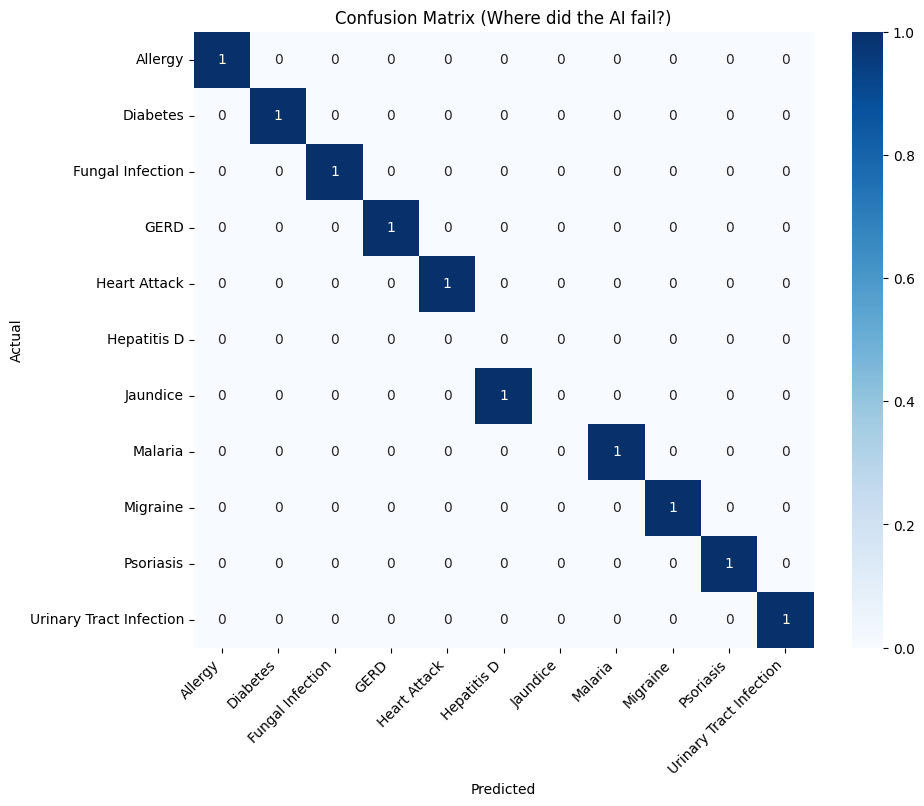

In [37]:
# Cell 7: Model Evaluation Script
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. DEFINE GROUND TRUTH (The "Answer Key")
# These are mapped accurately to the SymbiPredict dataset columns
test_data = [
    {
        "text": "I have high fever, chills, sweating, headache, and muscle pain", 
        "expected": "Malaria"
    },
    {
        "text": "severe throbbing headache, sensitivity to light, excessive hunger, stiff neck", 
        "expected": "Migraine"
    },
    {
        "text": "continuous sneezing, runny nose, shivering, chills, watering from eyes", 
        "expected": "Allergy"
    },
    {
        "text": "yellowish skin, vomiting, fatigue, dark urine, abdominal pain", 
        "expected": "Jaundice"
    },
    {
        "text": "chest pain, vomiting, breathlessness, sweating", 
        "expected": "Heart Attack"
    },
    {
        "text": "itching, skin rash, nodal skin eruptions, dischromic patches", 
        "expected": "Fungal Infection"
    },
    {
        "text": "burning micturition, bladder discomfort, foul smell of urine", 
        "expected": "Urinary Tract Infection"
    },
    {
        "text": "acidity, indigestion, stomach pain, ulcers on tongue", 
        "expected": "GERD"
    },
    {
        "text": "skin rash, joint pain, skin peeling, silver like dusting", 
        "expected": "Psoriasis"
    },
    {
        "text": "fatigue, weight loss, increased appetite, polyuria, irregular sugar level", 
        "expected": "Diabetes " # Note: The dataset has a space after 'Diabetes '
    }
]

print(f"🧪 Starting Evaluation on {len(test_data)} test cases...\n")

y_true = []
y_pred = []

# 2. RUN PREDICTIONS
for case in test_data:
    # Query ChromaDB
    results = disease_collection.query(
        query_texts=[case["text"]], 
        n_results=1
    )
    
    # Get Prediction
    if results['documents'][0]:
        predicted_disease = results['metadatas'][0][0]['name'].strip() # Strip extra spaces
        expected_disease = case["expected"].strip()
    else:
        predicted_disease = "Unknown"
        expected_disease = case["expected"].strip()
        
    y_true.append(expected_disease)
    y_pred.append(predicted_disease)
    
    # Print individual result
    is_correct = "✅" if expected_disease == predicted_disease else "❌"
    print(f"{is_correct} Input: '{case['text'][:40]}...'") 
    print(f"   Pred: {predicted_disease} | True: {expected_disease}")

# 3. CALCULATE METRICS
print("\n" + "="*40)
print("📊 MODEL PERFORMANCE REPORT")
print("="*40)

# A. Classification Report
unique_labels = sorted(list(set(y_true + y_pred)))
report = classification_report(y_true, y_pred, labels=unique_labels, zero_division=0)
print(report)

# B. Simple Accuracy
correct_count = sum([1 for i in range(len(y_true)) if y_true[i] == y_pred[i]])
accuracy = correct_count / len(y_true)
print(f"\n🎯 Overall Accuracy: {accuracy * 100:.2f}%")

# 4. VISUALIZE CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Where did the AI fail?)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [47]:
# Cell 8: Production-Grade Integrity Tests (Final Version)
from fastapi.testclient import TestClient
import time
import sys

client = TestClient(app)

def assert_response(name, response, expected_status=200, required_keys=[]):
    """Helper to enforce strict API contracts"""
    print(f"🔹 {name}...", end=" ")
    
    # 1. Status Check
    if response.status_code != expected_status:
        print(f"❌ FAILED\n   Expected Status {expected_status}, got {response.status_code}")
        print(f"   Response: {response.text}")
        return None
    
    # 2. JSON Parsing
    try:
        data = response.json()
    except:
        print("❌ FAILED (Invalid JSON)")
        return None
        
    # 3. Schema Validation
    missing = [key for key in required_keys if key not in data]
    if missing:
        print(f"❌ FAILED (Schema Violation)\n   Missing keys: {missing}")
        return None
        
    print(f"✅ PASSED ({response.elapsed.total_seconds()*1000:.1f}ms)")
    return data

print("🚀 RUNNING PRODUCTION INTEGRITY CHECKS\n" + "="*50)

# TEST 1: System Health
assert_response("Health Check", client.get("/"), 200, ["status", "backend"])

# TEST 2: Disease Prediction
print("\n🩺 Testing Disease AI Contract:")
data = assert_response(
    "Predict 'Stiff Neck'", 
    client.post("/predict_disease", json={"symptoms": "stiff neck, high fever"}),
    200, 
    ["found", "disease", "confidence", "patient_response", "doctor_report"]
)

if data:
    print(f"   📝 Patient Msg: \"{data['patient_response'][:60]}...\"")
    print(f"   📝 Doctor Rpt:  \"{data['doctor_report'][:60]}...\"")

# TEST 3: Medicine Substitute Finder (Updated)
print("\n💊 Testing Medicine Engine:")
# Use a name from your csv, e.g., 'augmentin 625 duo tablet'
target_med = "augmentin 625 duo tablet" 

data_med = assert_response(
    f"Search '{target_med}'",
    client.post("/find_generic", json={"brand_name": target_med}),
    200,
    # UPDATED CONTRACT: No price, looking for 'alternatives'
    ["status", "original_brand", "alternatives", "message"] 
)

if data_med:
    if data_med["status"] == "Alternatives Found":
        alts = data_med['alternatives']
        print(f"   ✅ Success! Found {len(alts)} substitutes.")
        print(f"   💊 Top 3 Suggestions: {', '.join(alts[:3])}")
    else:
        print(f"   ℹ️ Status: {data_med['status']}")

# TEST 4: 404 Handling
print("\n🛡️ Testing Error Handling:")
assert_response(
    "Unknown Medicine",
    client.post("/find_generic", json={"brand_name": "FakeMedicine123"}),
    404,
    ["detail"]
)

print("\n" + "="*50)
print("✅ SYSTEM READY FOR DEPLOYMENT")

2026-01-29 14:52:11,293 | INFO | HTTP Request: GET http://testserver/ "HTTP/1.1 200 OK"


🚀 RUNNING PRODUCTION INTEGRITY CHECKS
🔹 Health Check... ✅ PASSED (14.5ms)

🩺 Testing Disease AI Contract:


Batches: 100%|██████████| 1/1 [00:00<00:00, 44.34it/s]
2026-01-29 14:52:11,422 | INFO | ⚡ CACHE HIT! (Distance: 0.0000)
2026-01-29 14:52:11,426 | INFO | HTTP Request: POST http://testserver/predict_disease "HTTP/1.1 200 OK"


🔹 Predict 'Stiff Neck'... ✅ PASSED (129.7ms)
   📝 Patient Msg: "I'm so sorry to hear that you're experiencing a stiff neck a..."
   📝 Doctor Rpt:  "The patient is presenting with a stiff neck and high fever, ..."

💊 Testing Medicine Engine:


2026-01-29 14:52:11,507 | INFO | HTTP Request: POST http://testserver/find_generic "HTTP/1.1 200 OK"


🔹 Search 'augmentin 625 duo tablet'... ✅ PASSED (81.0ms)
   ✅ Success! Found 5 substitutes.
   💊 Top 3 Suggestions: Penciclav 500 mg/125 mg Tablet, Moxikind-CV 625 Tablet, Moxiforce-CV 625 Tablet

🛡️ Testing Error Handling:


2026-01-29 14:52:11,671 | INFO | HTTP Request: POST http://testserver/find_generic "HTTP/1.1 404 Not Found"


🔹 Unknown Medicine... ✅ PASSED (161.3ms)

✅ SYSTEM READY FOR DEPLOYMENT
